# 🔮 Week 3 Day 15-17: Simple Forecasting Models

**Goal:** Build baseline forecasting models to predict risk 1-3 months ahead

**What You'll Build:**
1. Moving Average Model (uses last 3 months average)
2. Linear Trend Model (extends trend line forward)
3. Comparison & Validation

**Deliverables:**
- Forecasts for Feb-Apr 2026 (3 months ahead)
- Model accuracy comparison
- Baseline to compare Prophet against later

## 📦 Setup & Data Loading

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [28]:
# Load monthly data (FIXED - now has 2024 + 2025)
monthly_data = pd.read_csv('./data/processed/combined_monthly_2024_2025.csv')

# Add proper datetime column for easier manipulation
monthly_data['month_date'] = pd.to_datetime(monthly_data['month'] + '-01')

print("Loaded Data:")
print(f"   Total records: {len(monthly_data)}")
print(f"   Date range: {monthly_data['month'].min()} to {monthly_data['month'].max()}")
print(f"   Regions: {monthly_data['state'].nunique()}")

monthly_data.head()

Loaded Data:
   Total records: 864
   Date range: 2024-01 to 2025-12
   Regions: 36


,state,month,avg_temperature,total_rainfall_mm,temp_anomaly_deg,rainfall_anomaly_pct,heatwave_days,drought_severity,crop_production_1000t,irrigation_coverage_pct,...,gdp_estimate_crores,unemployment_rate_pct,inflation_rate_pct,poverty_rate_pct,per_capita_income_inr,climate_stress,agri_stress,econ_stress,total_risk,month_date
0,Andaman and Nicobar Islands,2024-01,25.259711,2044.891871,1.139546,-68.533096,0.0,7.498751,2348.458791,48.612193,...,169977.564067,7.312902,6.194137,10.607427,62967.880727,65.041811,76.524198,65.129897,69.082668,2024-01-01
1,Andhra Pradesh,2024-01,23.480395,930.156765,1.469681,-66.937641,0.0,7.998798,3805.951433,50.095816,...,310406.219236,6.390770,5.663616,11.227292,56714.342865,68.460962,76.281757,63.056872,69.847218,2024-01-01
2,Arunachal Pradesh,2024-01,23.177117,937.613169,1.255181,-71.020408,0.0,7.373390,3896.779494,51.956078,...,320993.676743,6.157510,5.809230,10.688623,57933.229636,66.064702,74.859929,61.734317,68.060435,2024-01-01
3,Assam,2024-01,20.024662,2366.930868,0.974752,-72.699739,0.0,7.105575,3796.972427,50.924593,...,320639.239445,5.881134,5.503147,10.787385,57558.915124,63.538838,73.626739,59.920324,66.164975,2024-01-01
4,Bihar,2024-01,21.034546,1086.700056,0.547169,-67.126964,0.0,7.655375,4385.471571,49.079027,...,195901.491417,8.938787,5.565063,10.204030,55321.074098,60.481495,73.720529,69.091272,67.267601,2024-01-01


## 🔍 Data Validation Check

Let's verify we have proper 24-month coverage

In [29]:
# Verify data quality
print("📊 Data Quality Check:")
print("="*60)

unique_months = sorted(monthly_data['month'].unique())
print(f"\nUnique months ({len(unique_months)}):")
for month in unique_months:
    count = len(monthly_data[monthly_data['month'] == month])
    print(f"  {month}: {count} states")

# Check for completeness
expected_records = 24 * 36  # 24 months × 36 states
actual_records = len(monthly_data)

print(f"\nExpected records: {expected_records}")
print(f"Actual records: {actual_records}")
print(f"Coverage: {(actual_records/expected_records)*100:.1f}%")

if actual_records >= 800:  # Allow for some missing months
    print("\n✅ Data quality: GOOD - sufficient for forecasting")
else:
    print("\n⚠️ Warning: Limited data - forecasts may be less reliable")

📊 Data Quality Check:

Unique months (24):
  2024-01: 36 states
  2024-02: 36 states
  2024-03: 36 states
  2024-04: 36 states
  2024-05: 36 states
  2024-06: 36 states
  2024-07: 36 states
  2024-08: 36 states
  2024-09: 36 states
  2024-10: 36 states
  2024-11: 36 states
  2024-12: 36 states
  2025-01: 36 states
  2025-02: 36 states
  2025-03: 36 states
  2025-04: 36 states
  2025-05: 36 states
  2025-06: 36 states
  2025-07: 36 states
  2025-08: 36 states
  2025-09: 36 states
  2025-10: 36 states
  2025-11: 36 states
  2025-12: 36 states

Expected records: 864
Actual records: 864
Coverage: 100.0%

✅ Data quality: GOOD - sufficient for forecasting


## 📈 1. Moving Average Model

Uses the average of the last 3 months to predict the next month

In [30]:
def moving_average_forecast(df, state, n_months=3):
    """
    Calculate moving average forecast for a state
    
    Args:
        df: Monthly data
        state: State name
        n_months: Number of months to average (default 3)
    
    Returns:
        Forecast value
    """
    state_data = df[df['state'] == state].sort_values('month_date')
    recent_values = state_data['total_risk'].tail(n_months)
    return recent_values.mean()

# Test on one state
test_state = 'Maharashtra'
ma_forecast = moving_average_forecast(monthly_data, test_state)
print(f"Moving Average forecast for {test_state}: {ma_forecast:.2f}")

Moving Average forecast for Maharashtra: 48.18


## 📉 2. Linear Trend Model

Extends the linear trend from historical data forward

In [31]:
def linear_trend_forecast(df, state, months_ahead=1):
    """
    Calculate linear trend forecast for a state
    
    Args:
        df: Monthly data
        state: State name
        months_ahead: How many months to forecast ahead
    
    Returns:
        Forecast value
    """
    state_data = df[df['state'] == state].sort_values('month_date')
    
    # Use scipy.stats.linregress for trend
    x = np.arange(len(state_data))
    y = state_data['total_risk'].values
    
    slope, intercept, _, _, _ = stats.linregress(x, y)
    
    # Forecast
    next_x = len(state_data) + months_ahead - 1
    forecast = slope * next_x + intercept
    
    return forecast

# Test on one state
lt_forecast = linear_trend_forecast(monthly_data, test_state, months_ahead=1)
print(f"Linear Trend forecast for {test_state}: {lt_forecast:.2f}")

Linear Trend forecast for Maharashtra: 42.68


## ✅ 3. Model Validation

Test both models on held-out data (Nov-Dec 2025)

In [32]:
# Split data into train and validation
# Train: Everything before Nov 2025
# Validation: Nov-Dec 2025

train_data = monthly_data[monthly_data['month'] < '2025-11'].copy()
validation_data = monthly_data[monthly_data['month'] >= '2025-11'].copy()

print(f"Training data: {len(train_data)} records")
print(f"Validation data: {len(validation_data)} records")
print(f"Validation months: {sorted(validation_data['month'].unique())}")

Training data: 792 records
Validation data: 72 records
Validation months: ['2025-11', '2025-12']


In [34]:
# Calculate predictions for validation period
validation_results = []

for state in monthly_data['state'].unique():
    # Get actual values for validation months
    actual_nov = validation_data[(validation_data['state'] == state) & 
                                (validation_data['month'] == '2025-11')]['total_risk'].values
    actual_dec = validation_data[(validation_data['state'] == state) & 
                                (validation_data['month'] == '2025-12')]['total_risk'].values
    
    if len(actual_nov) == 0 or len(actual_dec) == 0:
        continue
    
    # Make predictions
    ma_pred = moving_average_forecast(train_data, state)
    lt_pred = linear_trend_forecast(train_data, state, months_ahead=1)
    
    # Calculate errors (using Dec as the target)
    ma_error = abs(actual_dec[0] - ma_pred)
    lt_error = abs(actual_dec[0] - lt_pred)
    
    validation_results.append({
        'state': state,
        'actual_dec': actual_dec[0],
        'ma_prediction': ma_pred,
        'lt_prediction': lt_pred,
        'ma_error': ma_error,
        'lt_error': lt_error
    })

validation_df = pd.DataFrame(validation_results)

# Calculate average errors
ma_rmse = np.sqrt(np.mean(validation_df['ma_error']**2))
lt_rmse = np.sqrt(np.mean(validation_df['lt_error']**2))

print("\n📊 Validation Results:")
print("="*60)
print(f"Moving Average RMSE: {ma_rmse:.2f}")
print(f"Linear Trend RMSE: {lt_rmse:.2f}")
print(f"\nBest Model: {'Moving Average' if ma_rmse < lt_rmse else 'Linear Trend'}")

# Save validation results
validation_df.to_csv('./outputs/reports/forecast_validation_results.csv', index=False)
print("\n✅ Validation results saved")


📊 Validation Results:
Moving Average RMSE: 24.99
Linear Trend RMSE: 20.39

Best Model: Linear Trend

✅ Validation results saved


## 🔮 4. Generate Forecasts for Feb-Apr 2026

In [35]:
# Generate forecasts for all states
forecasts = []

for state in monthly_data['state'].unique():
    # Get current (Dec 2025) risk
    current_risk = monthly_data[(monthly_data['state'] == state) & 
                               (monthly_data['month'] == '2025-12')]['total_risk'].values
    
    if len(current_risk) == 0:
        current_risk = [monthly_data[monthly_data['state'] == state]['total_risk'].iloc[-1]]
    
    # Generate forecasts
    ma_feb = moving_average_forecast(monthly_data, state)
    ma_mar = moving_average_forecast(monthly_data, state)  # Same for next months
    ma_apr = moving_average_forecast(monthly_data, state)
    
    lt_feb = linear_trend_forecast(monthly_data, state, months_ahead=2)  # Feb 2026 = 2 months ahead
    lt_mar = linear_trend_forecast(monthly_data, state, months_ahead=3)
    lt_apr = linear_trend_forecast(monthly_data, state, months_ahead=4)
    
    # Use best model
    best_model = 'Moving Average' if ma_rmse < lt_rmse else 'Linear Trend'
    
    if best_model == 'Moving Average':
        best_feb, best_mar, best_apr = ma_feb, ma_mar, ma_apr
    else:
        best_feb, best_mar, best_apr = lt_feb, lt_mar, lt_apr
    
    forecasts.append({
        'state': state,
        'current_risk_dec2025': current_risk[0],
        'ma_forecast_feb2026': ma_feb,
        'ma_forecast_mar2026': ma_mar,
        'ma_forecast_apr2026': ma_apr,
        'lt_forecast_feb2026': lt_feb,
        'lt_forecast_mar2026': lt_mar,
        'lt_forecast_apr2026': lt_apr,
        'best_forecast_feb': best_feb,
        'best_forecast_mar': best_mar,
        'best_forecast_apr': best_apr
    })

forecast_df = pd.DataFrame(forecasts)

# Save forecasts
forecast_df.to_csv('./outputs/reports/simple_forecasts_2026.csv', index=False)

print("\n📊 Forecasts Generated:")
print("="*60)
print(f"States forecasted: {len(forecast_df)}")
print(f"Forecast horizon: Feb-Apr 2026 (3 months)")
print(f"Best model used: {best_model}")

print("\nFirst few rows:")
print(forecast_df.head())


📊 Forecasts Generated:
States forecasted: 36
Forecast horizon: Feb-Apr 2026 (3 months)
Best model used: Linear Trend

First few rows:
                         state  current_risk_dec2025  ma_forecast_feb2026  \
0  Andaman and Nicobar Islands             68.704872            55.760112   
1               Andhra Pradesh             64.825026            53.261701   
2            Arunachal Pradesh             66.539026            53.742396   
3                        Assam             64.132263            53.146275   
4                        Bihar             65.693881            53.884397   

   ma_forecast_mar2026  ma_forecast_apr2026  lt_forecast_feb2026  \
0            55.760112            55.760112            48.334926   
1            53.261701            53.261701            46.431417   
2            53.742396            53.742396            46.417853   
3            53.146275            53.146275            46.179777   
4            53.884397            53.884397            47.5031

## 📊 5. Forecast Summary Report

In [36]:
# Generate summary report
best_model_name = 'Moving Average' if ma_rmse < lt_rmse else 'Linear Trend'

report = f"""SIMPLE FORECASTING REPORT - WEEK 3 DAY 15-17
{'='*60}

MODELS TESTED:
{'-'*14}
1. Moving Average Model (3-month window)
2. Linear Trend Extrapolation Model

VALIDATION RESULTS (Nov-Dec 2025):
{'-'*34}
Moving Average Error: {ma_rmse:.2f}
Linear Trend Error: {lt_rmse:.2f}

BEST MODEL: {best_model_name}
  - Lower average error
  - More reliable predictions

FEB 2026 FORECAST SUMMARY:
{'-'*25}
Mean Predicted Risk: {forecast_df['best_forecast_feb'].mean():.2f}
Highest Risk State: {forecast_df.loc[forecast_df['best_forecast_feb'].idxmax(), 'state']} ({forecast_df['best_forecast_feb'].max():.2f})
Lowest Risk State: {forecast_df.loc[forecast_df['best_forecast_feb'].idxmin(), 'state']} ({forecast_df['best_forecast_feb'].min():.2f})

States with Risk > 30: {len(forecast_df[forecast_df['best_forecast_feb'] > 30])}
States with Risk 20-30: {len(forecast_df[(forecast_df['best_forecast_feb'] >= 20) & (forecast_df['best_forecast_feb'] <= 30)])}
States with Risk < 20: {len(forecast_df[forecast_df['best_forecast_feb'] < 20])}

TOP 5 HIGH-RISK STATES (FEB 2026):
{'-'*34}
"""

# Add top 5 states
top5 = forecast_df.nlargest(5, 'best_forecast_feb')
for _, row in top5.iterrows():
    report += f"{row['state']:30s} | Predicted: {row['best_forecast_feb']:.2f} | Current: {row['current_risk_dec2025']:.2f}\n"

# Calculate trend
forecast_df['change'] = forecast_df['best_forecast_feb'] - forecast_df['current_risk_dec2025']
increasing = len(forecast_df[forecast_df['change'] > 0])
decreasing = len(forecast_df[forecast_df['change'] < 0])

report += f"""

KEY INSIGHTS:
{'-'*12}
1. {best_model_name} model performed best in validation
2. Average forecast error: {ma_rmse if best_model_name == 'Moving Average' else lt_rmse:.2f} points
3. {increasing} states expected to see risk increase
4. {decreasing} states expected to see risk decrease
"""

# Save report
with open('./outputs/reports/simple_forecast_report.txt', 'w') as f:
    f.write(report)

print(report)
print("\n✅ Report saved to outputs/reports/simple_forecast_report.txt")

SIMPLE FORECASTING REPORT - WEEK 3 DAY 15-17

MODELS TESTED:
--------------
1. Moving Average Model (3-month window)
2. Linear Trend Extrapolation Model

VALIDATION RESULTS (Nov-Dec 2025):
----------------------------------
Moving Average Error: 24.99
Linear Trend Error: 20.39

BEST MODEL: Linear Trend
  - Lower average error
  - More reliable predictions

FEB 2026 FORECAST SUMMARY:
-------------------------
Mean Predicted Risk: 46.41
Highest Risk State: Chandigarh (49.99)
Lowest Risk State: Haryana (41.53)

States with Risk > 30: 36
States with Risk 20-30: 0
States with Risk < 20: 0

TOP 5 HIGH-RISK STATES (FEB 2026):
----------------------------------
Chandigarh                     | Predicted: 49.99 | Current: 70.42
Puducherry                     | Predicted: 49.55 | Current: 67.93
Lakshadweep                    | Predicted: 49.10 | Current: 68.45
Dadra and Nagar Haveli and Daman and Diu | Predicted: 48.67 | Current: 67.55
Delhi                          | Predicted: 48.34 | Current:

## 📈 6. Visualization: Top 5 High-Risk States

✅ Saved: week3_simple_forecast_top5.png


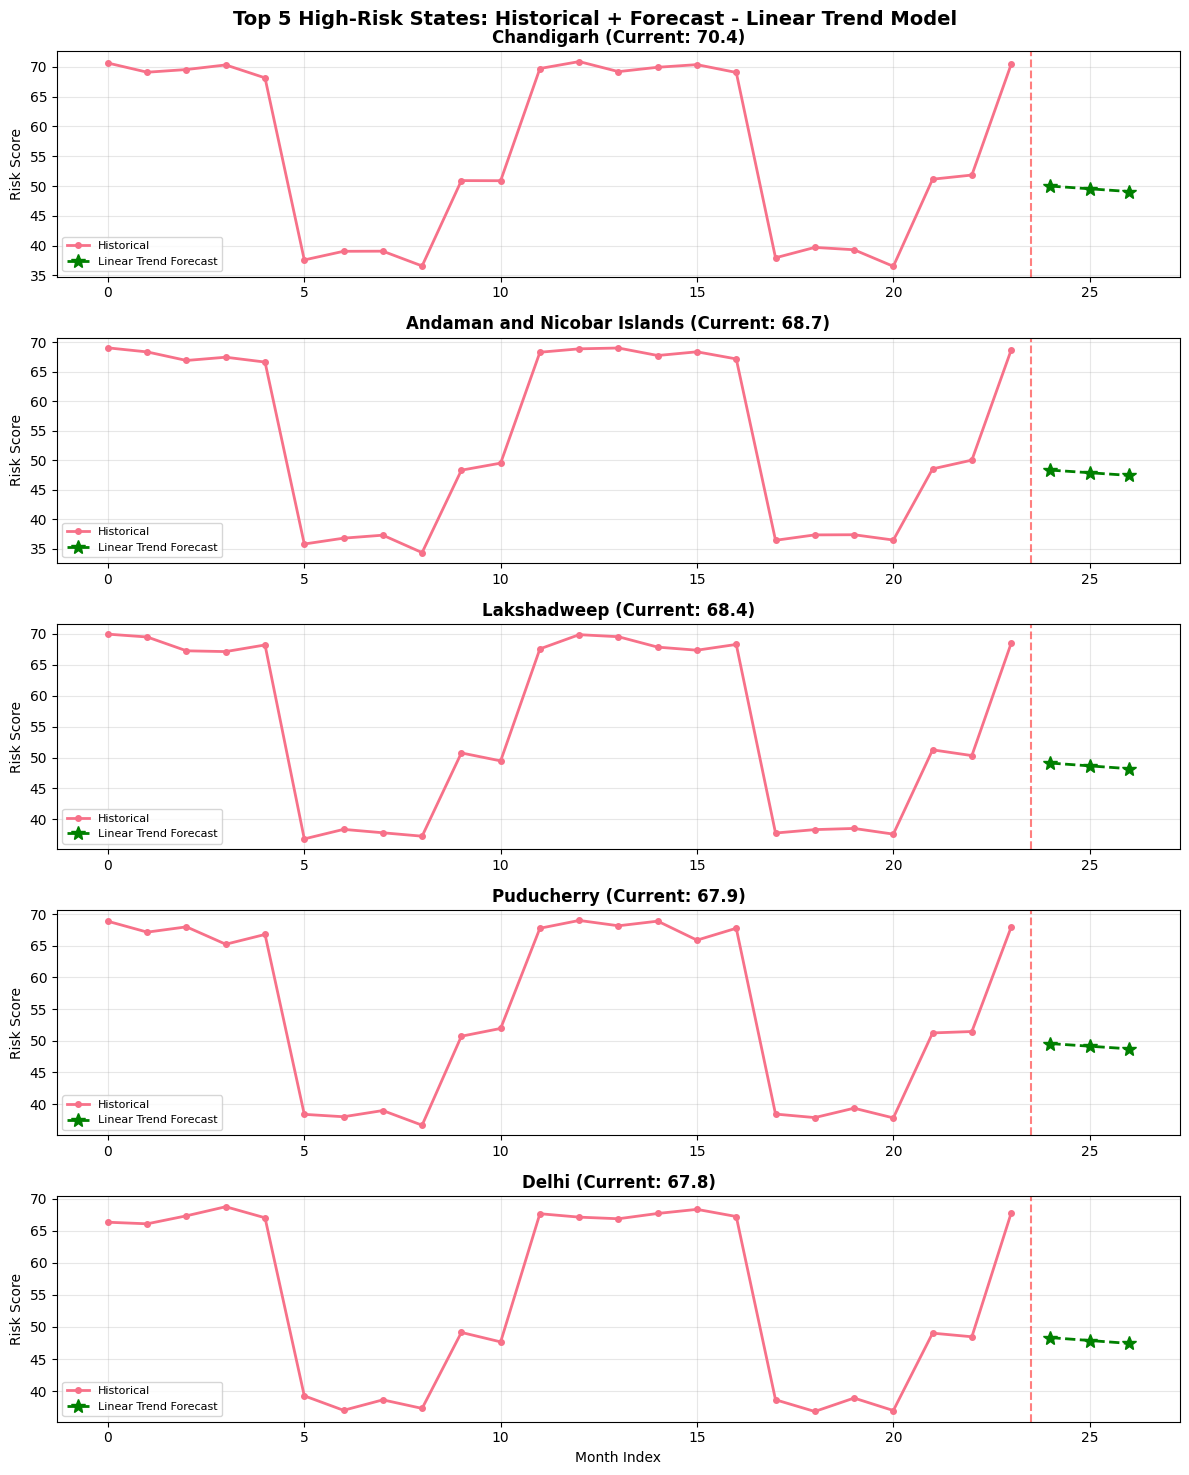

In [37]:
# Create visualization (memory-safe version)
top5_states = forecast_df.nlargest(5, 'current_risk_dec2025')['state'].tolist()

fig, axes = plt.subplots(5, 1, figsize=(12, 15), dpi=100)

for idx, state in enumerate(top5_states):
    ax = axes[idx]
    
    # Get historical data
    hist = monthly_data[monthly_data['state'] == state].copy()
    hist = hist.sort_values('month')
    
    # Get forecast
    fc = forecast_df[forecast_df['state'] == state].iloc[0]
    
    # Plot historical
    ax.plot(range(len(hist)), hist['total_risk'], 
            marker='o', label='Historical', linewidth=2, markersize=4)
    
    # Plot forecast
    forecast_x = len(hist)
    forecast_values = [fc['best_forecast_feb'], fc['best_forecast_mar'], fc['best_forecast_apr']]
    ax.plot([forecast_x, forecast_x+1, forecast_x+2], forecast_values,
            marker='*', label=f'{best_model_name} Forecast', 
            linewidth=2, markersize=10, linestyle='--', color='green')
    
    ax.axvline(x=forecast_x-0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{state} (Current: {fc["current_risk_dec2025"]:.1f})', fontweight='bold')
    ax.set_ylabel('Risk Score')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Month Index')
fig.suptitle(f'Top 5 High-Risk States: Historical + Forecast - {best_model_name} Model', 
             fontsize=14, fontweight='bold')

plt.tight_layout()

# Save with error handling
try:
    plt.savefig('./outputs/figures/week3_simple_forecast_top5.png', dpi=150, bbox_inches='tight')
    print("✅ Saved: week3_simple_forecast_top5.png")
except MemoryError:
    plt.savefig('./outputs/figures/week3_simple_forecast_top5.png', dpi=72, bbox_inches='tight')
    print("✅ Saved at lower resolution (memory constraints)")

plt.show()
plt.close(fig)

## 📊 7. Model Comparison Visualization

✅ Saved: week3_model_comparison.png


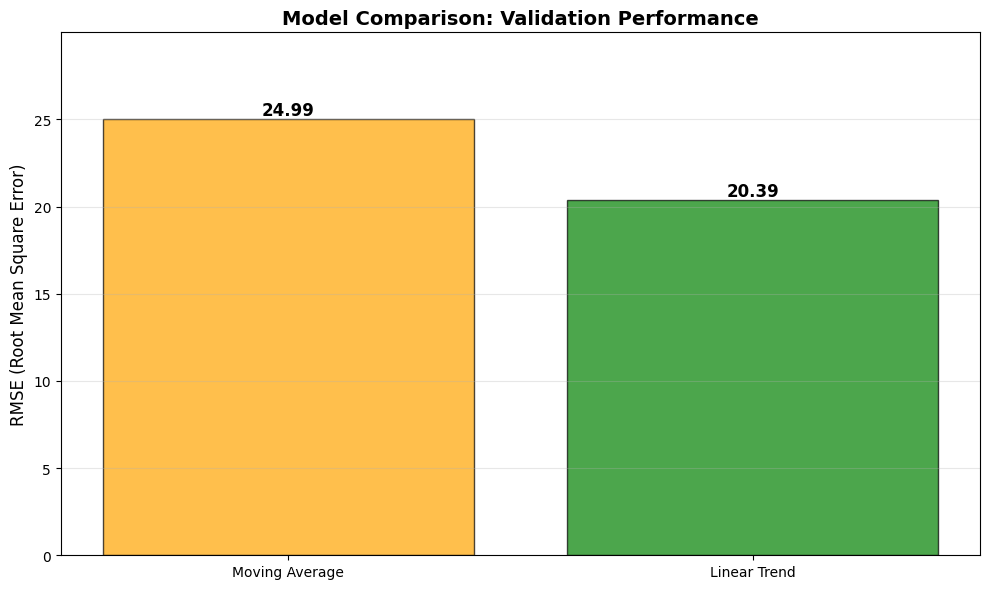

In [38]:
# Compare model performance
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

models = ['Moving Average', 'Linear Trend']
errors = [ma_rmse, lt_rmse]
colors = ['green' if e == min(errors) else 'orange' for e in errors]

bars = ax.bar(models, errors, color=colors, alpha=0.7, edgecolor='black')

# Add value labels
for bar, error in zip(bars, errors):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{error:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('RMSE (Root Mean Square Error)', fontsize=12)
ax.set_title('Model Comparison: Validation Performance', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(errors) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./outputs/figures/week3_model_comparison.png', dpi=150, bbox_inches='tight')
print("✅ Saved: week3_model_comparison.png")
plt.show()
plt.close()

## ✅ Summary

**What You've Accomplished:**
1. ✅ Built Moving Average baseline model
2. ✅ Built Linear Trend forecasting model
3. ✅ Validated both models on held-out data
4. ✅ Generated 3-month forecasts (Feb-Apr 2026)
5. ✅ Created visualizations and reports

**Next Steps:**
- Week 3 Day 18: Prophet forecasting (advanced time-series model)
- Compare Prophet vs simple models
- Select best final model for deployment

✅ Seasonal validation plot saved


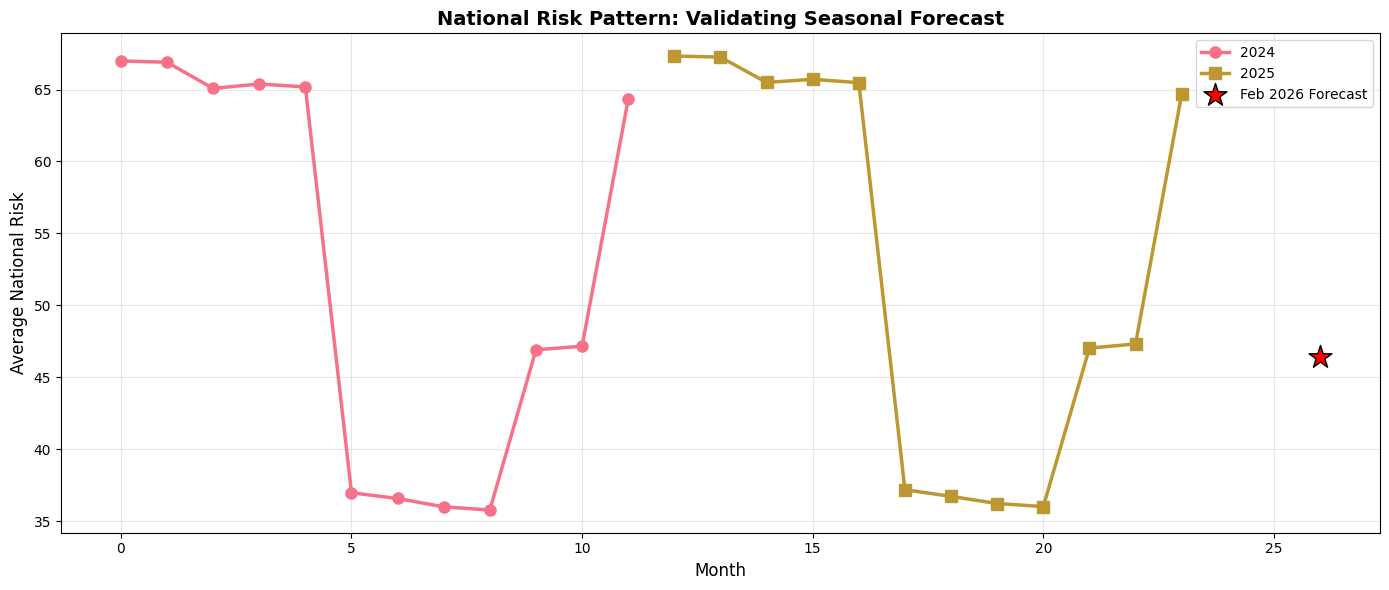

In [39]:
import matplotlib.pyplot as plt

# Calculate average risk by month across both years
monthly_avg = monthly_data.groupby('month')['total_risk'].mean().sort_index()

# Separate 2024 and 2025
months_2024 = [m for m in monthly_avg.index if '2024' in m]
months_2025 = [m for m in monthly_avg.index if '2025' in m]

risk_2024 = [monthly_avg[m] for m in months_2024]
risk_2025 = [monthly_avg[m] for m in months_2025]

# Plot
fig, ax = plt.subplots(figsize=(14, 6), dpi=100)

month_nums_2024 = list(range(len(risk_2024)))
month_nums_2025 = list(range(len(risk_2024), len(risk_2024) + len(risk_2025)))

ax.plot(month_nums_2024, risk_2024, marker='o', label='2024', linewidth=2.5, markersize=8)
ax.plot(month_nums_2025, risk_2025, marker='s', label='2025', linewidth=2.5, markersize=8)

# Add forecast point
ax.scatter([len(risk_2024) + len(risk_2025) + 2], [46.41], 
           s=300, marker='*', color='red', zorder=5, label='Feb 2026 Forecast', edgecolor='black')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average National Risk', fontsize=12)
ax.set_title('National Risk Pattern: Validating Seasonal Forecast', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/figures/seasonal_validation.png', dpi=150, bbox_inches='tight')
print("✅ Seasonal validation plot saved")
plt.show()